Modified from:

Fouilloux, A. (2026). EarthCARE to DGGS (v0.1.0). Zenodo.
https://doi.org/10.5281/zenodo.19709327

# Convert EarthCARE BMA_FLX_2B to HEALPix DGGS-Zarr

Broadband Radiometer (BBR) fluxes (using Multi-Spectral Imager (MSI) and Atmospheric Lidar (ATLID)) Level 2B (L2B) product

### Product Description

Providing instantaneous top-of-atmosphere (TOA) shortwave (SW) and longwave (LW) fluxes for the three BBR views (fore/nadir/aft) and combined, integrated spatially on four different integration domains (or spatial scales).

## Workflow
- Open EarthCARE Product
- Save the converted HEALPix data as DGGS-Zarr format following the
[zarr-conventions/dggs](https://github.com/zarr-conventions/dggs) specification,
and verify it can be re-opened with xdggs.

In [14]:
from pystac_client import Client
import earthcarekit as eck
import healpix_geo as hpxg
import numpy as np
import xarray as xr
import xdggs
import zarr
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import sys
sys.path.insert(0, '..')

from earthcare_dggs.convert import lonlat_to_healpix_cells
from earthcare_dggs.settings import ATLID_DEPTH, ELLIPSOID

## Search Catalog

In [2]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'


catalog = Client.open(catalog_url)

# Select one or more collection(s)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

# Select Product
PRODUCT = 'BMA_FLX_2B'


## Download Data

In [4]:
ORBIT = "06109D"
eck.ecdownload(file_type=PRODUCT , orbit_and_frame=ORBIT)

#======================================================================#
#                       EarthCARE Download Tool                        #
#                         earthcarekit 0.15.3                          #
#======================================================================#
# Settings
# - is_download=True
# - is_overwrite=False
# - is_unzip=True
# - is_delete=True
# - is_create_subdirs=True
# - is_log=False
# - is_debug=False
# - is_export_results=False
# - idx_selected_input=None
# - config_filepath=</home/k/k204228/.config/earthcarekit/default_config.toml>
# - data_dirpath=</home/k/k204228/EarthCARE/data>

+----------------------------------------------------------------------+
| STEP 1/2 - Search products                       2026-04-24 09:57:52 |
+----------------------------------------------------------------------+

*[1/1] Search request: BMA_FLX_2B, frame=D, orbits=[6109]
 [1/1] Files found in collection 'EarthCAREL2Validated_MAAP': 1

List of files found (tot

## Search and verify downloaded Data

In [5]:
result = eck.search_product(file_type=PRODUCT , orbit_and_frame=ORBIT)
print(f"{PRODUCT }: {result.filepath[0]}")

BMA_FLX_2B: /home/k/k204228/EarthCARE/data/level2b/BMA_FLX_2B/2025/06/25/BA/ECA_EXBA_BMA_FLX_2B_20250625T135845Z_20250929T235100Z_06109D/ECA_EXBA_BMA_FLX_2B_20250625T135845Z_20250929T235100Z_06109D.h5


## Read

In [6]:
for file_type in [PRODUCT]:
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with xr.open_dataset(result.filepath[0], group="ScienceData/AssessmentResolution") as ds:
            print(f"\n{'='*60}")
            print(f"{file_type}")
            print(f"{'='*60}")
            print(f"Dimensions: {dict(ds.sizes)}")
            print(f"Lat: shape={ds['latitude'].shape}, range=[{float(ds['latitude'].min()):.1f}, {float(ds['latitude'].max()):.1f}]")
            print(f"Lon: shape={ds['longitude'].shape}, range=[{float(ds['longitude'].min()):.1f}, {float(ds['longitude'].max()):.1f}]")
            print(f"\n2D variables (along_track, vertical):")
            for v in ds.data_vars:
                if ds[v].dims == ("along_track", "vertical"):
                    print(f"  {v}: shape={ds[v].shape}, dtype={ds[v].dtype}")
    except Exception as e:
        print(f"\n{file_type}: not available ({e})")


BMA_FLX_2B
Dimensions: {'along_track': 5322, 'msi_channel': 7, 'primary_surfaces': 2, 'bbr_direction': 3}
Lat: shape=(5322,), range=[21.7, 68.2]
Lon: shape=(5322,), range=[-0.7, 17.4]

2D variables (along_track, vertical):


In [7]:
result = eck.search_product(file_type=PRODUCT, orbit_and_frame=ORBIT)
with xr.open_dataset(result.filepath[0], group="ScienceData/AssessmentResolution") as ds:
    atl = ds.load()

print(f"Dimensions: {dict(atl.sizes)}")
print(f"Lat: [{float(atl['latitude'].min()):.1f}, {float(atl['latitude'].max()):.1f}]")
print(f"Lon: [{float(atl['longitude'].min()):.1f}, {float(atl['longitude'].max()):.1f}]")
print(f"\n1D variables (along_track, vertical):")
for v in atl.data_vars:
    if atl[v].dims == ("along_track",):
        print(f"  {v}: shape={atl[v].shape}")

Dimensions: {'along_track': 5322, 'msi_channel': 7, 'primary_surfaces': 2, 'bbr_direction': 3}
Lat: [21.7, 68.2]
Lon: [-0.7, 17.4]

1D variables (along_track, vertical):
  cloud_cover: shape=(5322,)
  MSI_cloud_top_height_mean: shape=(5322,)
  MSI_cloud_top_height_error: shape=(5322,)
  ATLID_cloud_top_height: shape=(5322,)
  latitude: shape=(5322,)
  longitude: shape=(5322,)
  time: shape=(5322,)
  geoid_offset: shape=(5322,)
  solar_reference_level_height: shape=(5322,)
  thermal_reference_level_height: shape=(5322,)
  solar_combined_top_of_atmosphere_flux: shape=(5322,)
  solar_combined_top_of_atmosphere_flux_error: shape=(5322,)
  solar_combined_top_of_atmosphere_flux_quality_status: shape=(5322,)
  thermal_combined_top_of_atmosphere_flux: shape=(5322,)
  thermal_combined_top_of_atmosphere_flux_error: shape=(5322,)
  thermal_combined_top_of_atmosphere_flux_quality_status: shape=(5322,)
  quality_status: shape=(5322,)


In [8]:
prof_cell_ids = lonlat_to_healpix_cells(
    atl["longitude"].values, atl["latitude"].values,
    depth=ATLID_DEPTH, ellipsoid=ELLIPSOID,
)

unique_cells = np.unique(prof_cell_ids)
print(f"HEALPix depth {ATLID_DEPTH}: {len(atl.along_track)} profiles → {len(unique_cells)} unique cells")
print(f"Average profiles per cell: {len(atl.along_track) / len(unique_cells):.1f}")

# Add cell_ids as coordinate
atl_healpix = atl.assign_coords(cell_ids=("along_track", prof_cell_ids))
atl_healpix.attrs.update({
    "healpix_level": ATLID_DEPTH,
    "healpix_indexing": "nested",
    "healpix_ellipsoid": ELLIPSOID,
})

print(f"\nDataset with cell_ids coordinate:")
print(atl_healpix)

HEALPix depth 14: 5322 profiles → 5322 unique cells
Average profiles per cell: 1.0

Dataset with cell_ids coordinate:
<xarray.Dataset> Size: 3MB
Dimensions:                                                 (along_track: 5322,
                                                             msi_channel: 7,
                                                             primary_surfaces: 2,
                                                             bbr_direction: 3)
Coordinates:
    cell_ids                                                (along_track) uint64 43kB ...
Dimensions without coordinates: along_track, msi_channel, primary_surfaces,
                                bbr_direction
Data variables: (12/46)
    MSI_clear_radiance_mean                                 (along_track, msi_channel) float32 149kB ...
    MSI_cloud_radiance_mean                                 (along_track, msi_channel) float32 149kB ...
    MSI_allsky_radiance_mean                                (along_track, msi_

In [9]:
# Add metadata
atl_healpix.attrs.update({
    "source": "EarthCARE MSI L2A",
    "healpix_level": ATLID_DEPTH,
    "healpix_indexing": "nested",
    "healpix_ellipsoid": ELLIPSOID,
    "orbit_and_frame": ORBIT,
})

# Add xdggs index
atl_healpix = xdggs.decode(
    atl_healpix,
    grid_info=xdggs.HealpixInfo(level=ATLID_DEPTH, indexing_scheme="nested"),
)

## Save to DGGS ZARR

In [10]:
# Encode with xdggs convention
atl_encoded = xdggs.encode(atl_healpix, "xdggs")

# Write to Zarr
output_path = f"earthcare_BMA_FLX_2B_{ORBIT}.zarr"
atl_encoded.to_zarr(output_path, mode="w", consolidated=False)

# Add DGGS Zarr convention metadata (compatible with legacy-converters format)
dggs_convention = {
    "uuid": "7b255807-140c-42ca-97f6-7a1cfecdbc38",
    "name": "dggs",
    "schema_url": "https://raw.githubusercontent.com/zarr-conventions/dggs/refs/tags/v1/schema.json",
    "spec_url": "https://github.com/zarr-conventions/dggs/blob/v1/README.md",
    "description": "Discrete Global Grid Systems convention for zarr",
}

dggs_meta = {
    "name": "healpix",
    "refinement_level": ATLID_DEPTH,
    "indexing_scheme": "nested",
    "ellipsoid": {
        "name": "wgs84",
        "semimajor_axis": 6378137.0,
        "inverse_flattening": 298.257223563,
    },
    "spatial_dimension": "cell_ids",
    "coordinate": "cell_ids",
    "compression": "none",
}

root = zarr.open_group(output_path, mode="r+")
root.attrs["zarr_conventions"] = [dggs_convention]
root.attrs["dggs"] = dggs_meta

print(f"Saved to {output_path}")
print(f"\nDGGS metadata: {dggs_meta}")

Saved to earthcare_BMA_FLX_2B_06109D.zarr

DGGS metadata: {'name': 'healpix', 'refinement_level': 14, 'indexing_scheme': 'nested', 'ellipsoid': {'name': 'wgs84', 'semimajor_axis': 6378137.0, 'inverse_flattening': 298.257223563}, 'spatial_dimension': 'cell_ids', 'coordinate': 'cell_ids', 'compression': 'none'}


## Plot Data

In [11]:
ds_healpix = xr.open_dataset("earthcare_BMA_FLX_2B_" +ORBIT +".zarr", consolidated=False)
ds_healpix

<xarray.Dataset> Size: 3MB
Dimensions:                                                 (along_track: 5322,
                                                             msi_channel: 7,
                                                             bbr_direction: 3,
                                                             primary_surfaces: 2)
Coordinates:
    cell_ids                                                (along_track) uint64 43kB ...
Dimensions without coordinates: along_track, msi_channel, bbr_direction,
                                primary_surfaces
Data variables: (12/46)
    ATLID_cloud_top_height                                  (along_track) float32 21kB ...
    MSI_clear_radiance_mean                                 (along_track, msi_channel) float32 149kB ...
    MSI_allsky_radiance_quality_status                      (along_track, msi_channel) float32 149kB ...
    MSI_allsky_radiance_mean                                (along_track, msi_channel) float32 149kB ...
    MSI_clear_radiance_quality_status                       (along_track, msi_channel) float32 149kB ...
    MSI_allsky_radiance_error                               (along_track, msi_channel) float32 149kB ...
    ...                                                      ...
    thermal_top_of_atmosphere_flux_quality_status           (along_track, bbr_direction) float32 64kB ...
    thermal_top_of_atmosphere_flux                          (along_track, bbr_direction) float32 64kB ...
    thermal_top_of_atmosphere_flux_error                    (along_track, bbr_direction) float32 64kB ...
    viewing_zenith_angle                                    (along_track, bbr_direction) float32 64kB ...
    thermal_reference_level_height                          (along_track) float32 21kB ...
    viewing_azimuth_angle                                   (along_track, bbr_direction) float32 64kB ...
Attributes:
    healpix_level:      14
    healpix_indexing:   nested
    healpix_ellipsoid:  WGS84
    source:             EarthCARE MSI L2A
    orbit_and_frame:    06109D
    zarr_conventions:   [{'uuid': '7b255807-140c-42ca-97f6-7a1cfecdbc38', 'na...
    dggs:               {'name': 'healpix', 'refinement_level': 14, 'indexing...

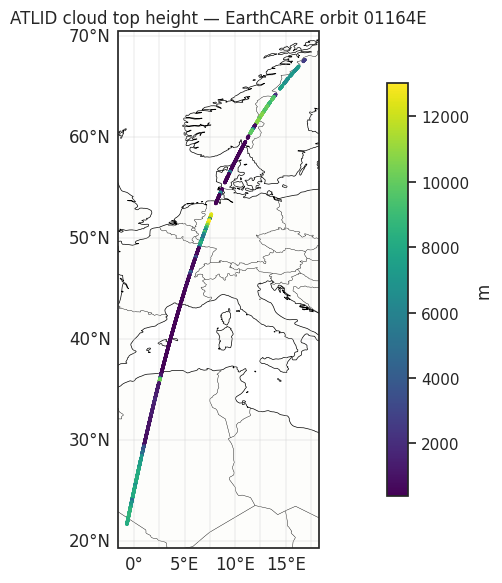

In [15]:
# Extract data
var      = ds_healpix["ATLID_cloud_top_height"].values
cell_ids = ds_healpix["cell_ids"].values

# Get lat/lon from cell_ids
theta, phi = hp.pix2ang(2**ds_healpix.attrs["healpix_level"], cell_ids.astype(int), nest=True)
lat = 90 - np.degrees(theta)
lon = np.degrees(phi)

# Plot
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})

#ax.coastlines(resolution="110m", linewidth=0.8)
#ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.1)
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
#ax.stock_img()

sc = ax.scatter(lon, lat, c=var, s=2, cmap="viridis",
                transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc, ax=ax, label=ds_healpix["ATLID_cloud_top_height"].attrs.get("units", ""),
             shrink=0.8)
ax.set_title("ATLID cloud top height — EarthCARE orbit 01164E")
plt.tight_layout()
plt.savefig("map.png")
plt.show()